#**Project 1** - House Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [2]:
data_dir =("/content/drive/MyDrive/Intern_P1/housing.csv")

In [3]:
data = pd.read_csv(data_dir)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Clean Data



In [5]:
# Fill missing values
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

In [6]:
# Remove capped values
data = data[data['median_house_value'] < 500001]

In [7]:
print(data.shape)
print(data.isnull().sum())

(19675, 10)
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


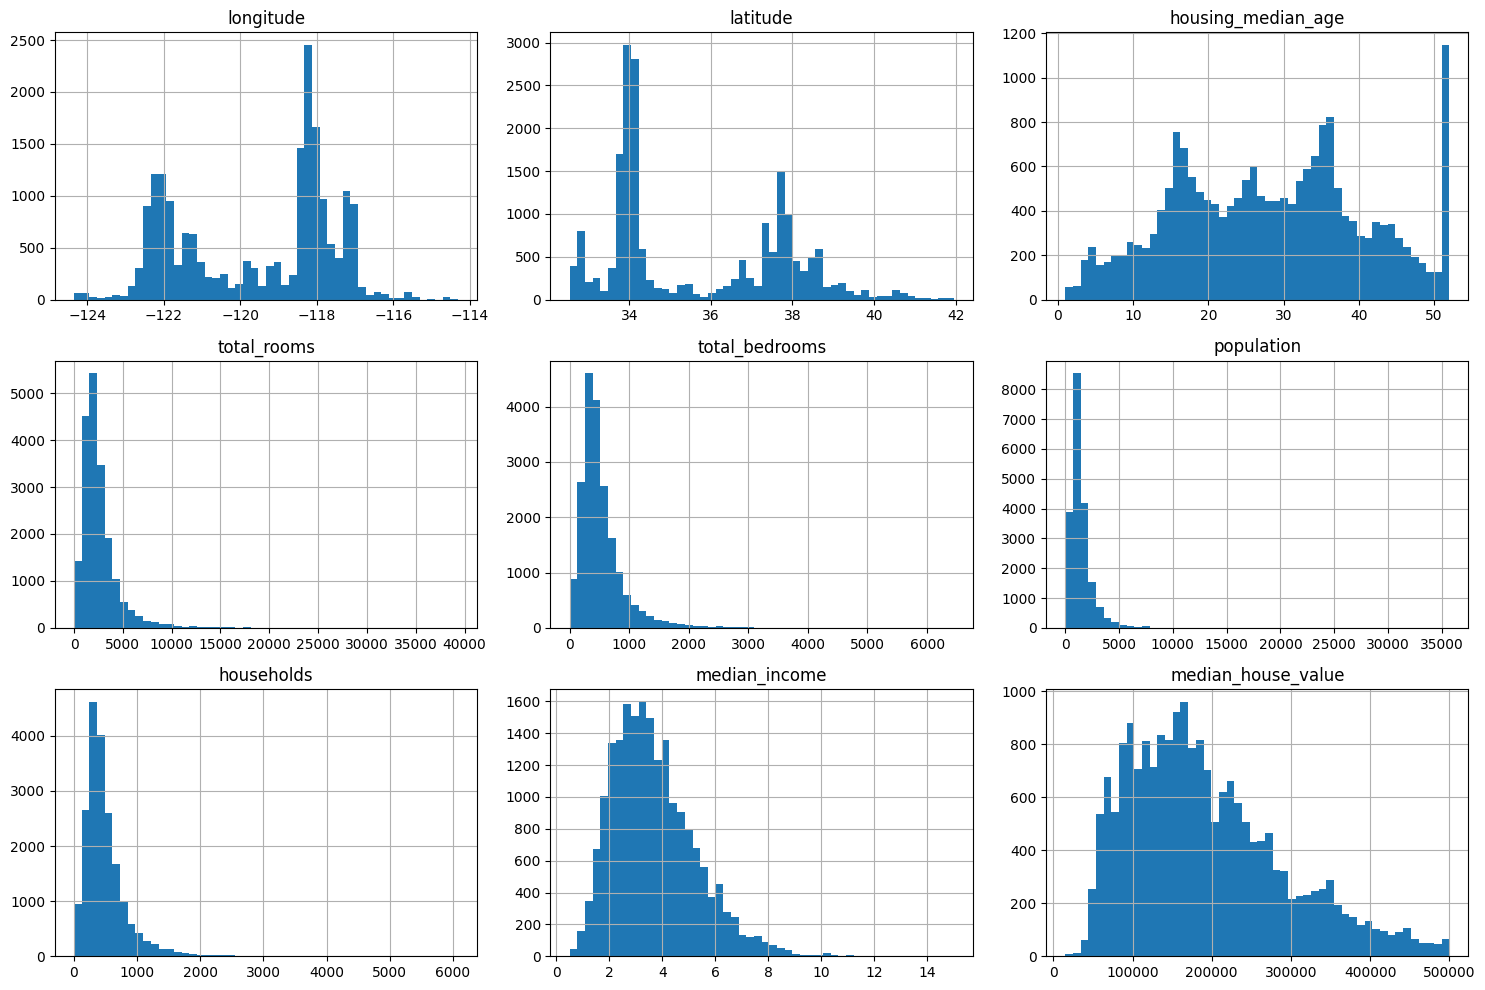

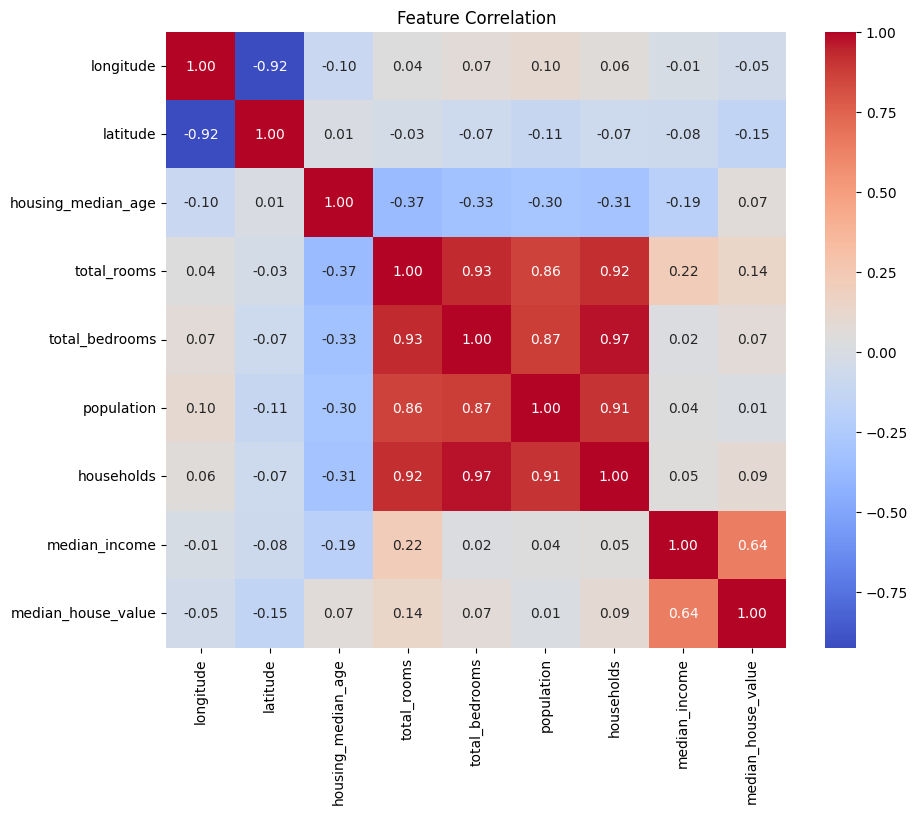

In [8]:
data.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

Feature Engineering + Encode

In [9]:
data['rooms_per_household']       = data['total_rooms']    / data['households']
data['bedrooms_per_room']         = data['total_bedrooms'] / data['total_rooms']
data['population_per_household']  = data['population']     / data['households']
data['rooms_per_person']          = data['total_rooms']    / data['population']
data['bedrooms_per_person']       = data['total_bedrooms'] / data['population']
data['income_per_room']           = data['median_income']  / data['total_rooms']

In [10]:
# Encode categorical
data = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,rooms_per_person,bedrooms_per_person,income_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,2.732919,0.400621,0.009460,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,2.956685,0.460641,0.001169,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,2.957661,0.383065,0.004947,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,2.283154,0.421147,0.004429,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,2.879646,0.495575,0.002364,0,0,1,0


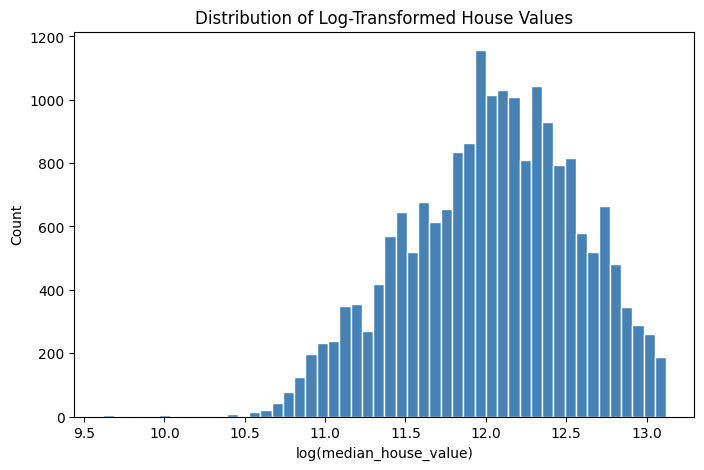

In [11]:
X = data.drop('median_house_value', axis=1)
y = np.log1p(data['median_house_value'])

# Visualize log-transformed target
plt.figure(figsize=(8, 5))
plt.hist(y, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('log(median_house_value)')
plt.ylabel('Count')
plt.title('Distribution of Log-Transformed House Values')
plt.show()

Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (15740, 18), Test: (3935, 18)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

print(f'Features after polynomial expansion: {X_train_poly.shape[1]}')

Features after polynomial expansion: 171


Train Model

In [15]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [16]:
y_pred_log  = model.predict(X_test_poly)
y_pred      = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae  = mean_absolute_error(y_test_orig, y_pred)
r2   = r2_score(y_test_orig, y_pred)

print(f'RMSE : ${rmse:,.0f}')
print(f'MAE  : ${mae:,.0f}')
print(f'R²   : {r2:.4f}')

RMSE : $57,526
MAE  : $38,926
R²   : 0.6681


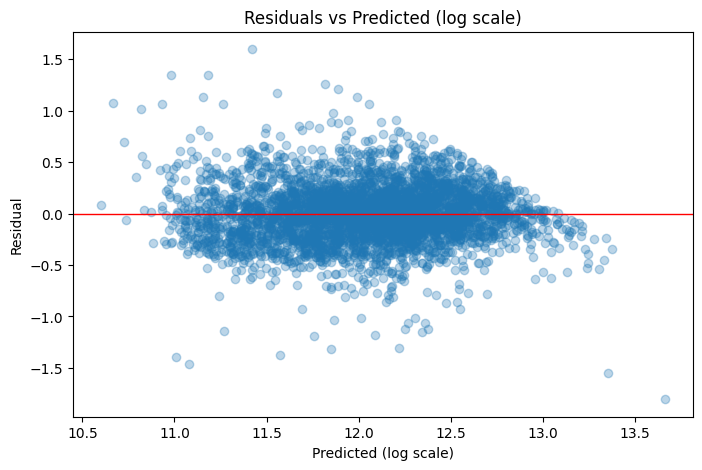

In [17]:
# Residual plot
residuals = y_test - y_pred_log

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_log, residuals, alpha=0.3)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted (log scale)')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (log scale)')
plt.show()

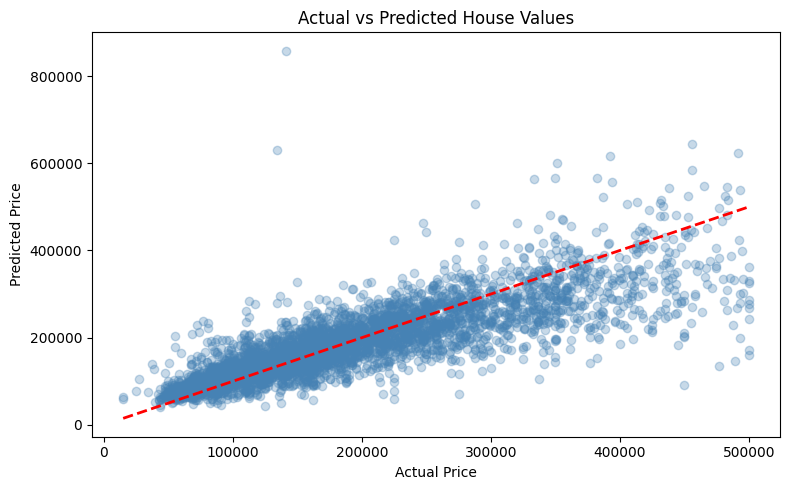

In [18]:
# Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_orig, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Values')
plt.tight_layout()
plt.show()

                                          Feature  Coefficient
                   total_bedrooms income_per_room     0.869054
                      total_rooms income_per_room     0.831891
                      households rooms_per_person     0.536336
  population_per_household ocean_proximity_INLAND     0.423929
                                    median_income     0.353240
                    total_rooms bedrooms_per_room     0.296462
      housing_median_age population_per_household     0.220977
                             latitude total_rooms     0.204937
population_per_household ocean_proximity_NEAR BAY     0.203885
                            longitude total_rooms     0.188586
               total_bedrooms bedrooms_per_person     0.187799
                     total_rooms rooms_per_person     0.185675
  ocean_proximity_INLAND ocean_proximity_NEAR BAY     0.173260
                       longitude rooms_per_person     0.155266
                        latitude rooms_per_person     0

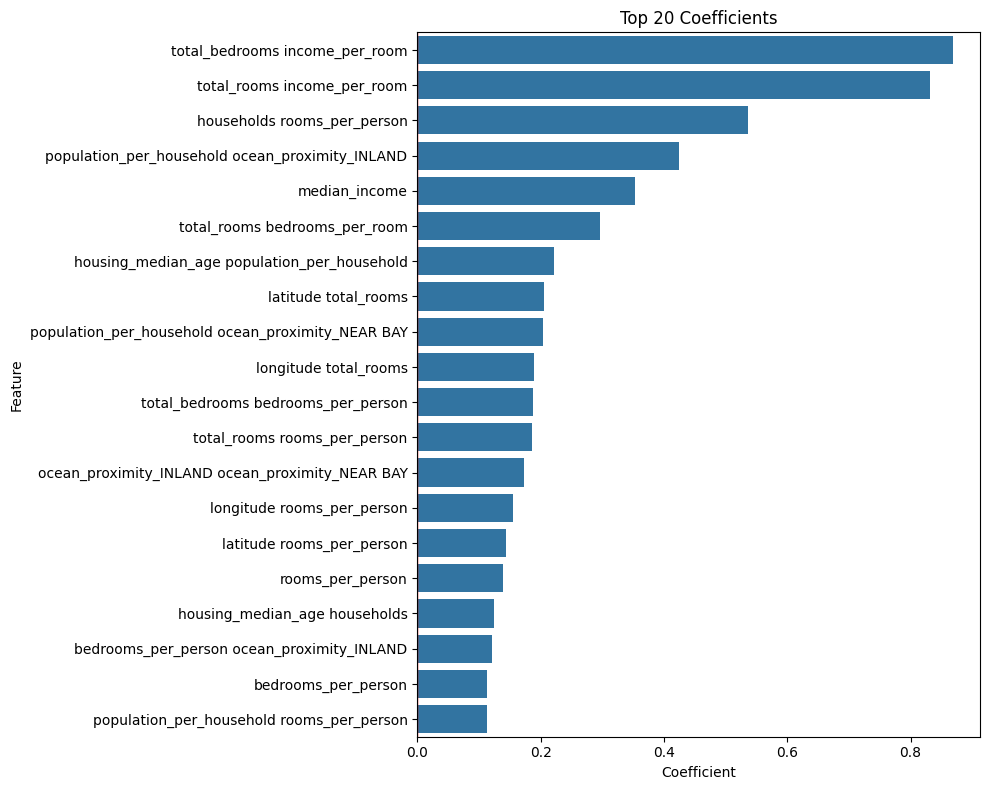

In [19]:
# Interpret Coefficients

feature_names = poly.get_feature_names_out(X.columns)
coeff_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coeff_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=coeff_df.head(20), x='Coefficient', y='Feature')
plt.title('Top 20 Coefficients')
plt.axvline(0, color='red', linewidth=1)
plt.tight_layout()
plt.show()

Save

In [23]:
save_path = '/content/drive/MyDrive/Intern_P1/'

joblib.dump(model,  save_path + 'house_price_model.pkl')
joblib.dump(scaler, save_path + 'scaler.pkl')
joblib.dump(poly,   save_path + 'poly.pkl')

print("Model, scaler and polynomial transformer saved")

Model, scaler and polynomial transformer saved


Load & Example Predictions

In [24]:
loaded_model  = joblib.load(save_path + 'house_price_model.pkl')
loaded_scaler = joblib.load(save_path + 'scaler.pkl')
loaded_poly   = joblib.load(save_path + 'poly.pkl')

sample        = X_test.sample(5, random_state=42)
sample_scaled = loaded_scaler.transform(sample)
sample_poly   = loaded_poly.transform(sample_scaled)

predicted_price = np.expm1(loaded_model.predict(sample_poly))
actual_price    = np.expm1(y_test.loc[sample.index])

results = pd.DataFrame({
    'Actual Price'   : actual_price.values,
    'Predicted Price': predicted_price,
    'Difference'     : actual_price.values - predicted_price
})
print(results.to_string(index=False))

 Actual Price  Predicted Price    Difference
     169500.0    219905.817220 -50405.817220
     216400.0    215200.355432   1199.644568
     480600.0    283680.480276 196919.519724
     185500.0    130171.351886  55328.648114
     119400.0    147884.372097 -28484.372097
